# Particionamiento y preprocesamiento para modelado

Este notebook toma como entrada el archivo `dataset_unificado_preparado.parquet`, generado en la etapa de unificación, limpieza y EDA. Su objetivo es definir las particiones de entrenamiento, validación y prueba, establecer las variables predictoras y objetivo, construir muestras manejables para experimentación y preparar las transformaciones que serán usadas posteriormente por los modelos de detección.

In [4]:
from pathlib import Path
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import duckdb
import pyarrow.parquet as pq
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
SECOND_RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [5]:
# Rutas del proyecto
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data"
PROCESSED_PATH = DATA_PATH / "processed"
INTERIM_PATH = DATA_PATH / "interim"
RESULTS_PATH = PROJECT_ROOT / "results"
MODELING_RESULTS_PATH = RESULTS_PATH / "modeling"
PREPROCESSING_RESULTS_PATH = RESULTS_PATH / "preprocessing"
MODELS_PATH = PROJECT_ROOT / "models"

for path in [DATA_PATH, PROCESSED_PATH, INTERIM_PATH, RESULTS_PATH, MODELING_RESULTS_PATH, PREPROCESSING_RESULTS_PATH, MODELS_PATH]:
    path.mkdir(parents=True, exist_ok=True)

prepared_parquet_path = (PROCESSED_PATH / "dataset_unificado_preparado.parquet")
prepared_parquet_path

WindowsPath('C:/Users/Laura/Documents/TrabajoGrado2026/TG2026/data/processed/dataset_unificado_preparado.parquet')

In [6]:
# Carpeta de código reutilizable
SRC_PATH = PROJECT_ROOT / "src"
SRC_PATH.mkdir(parents=True, exist_ok=True)

# Permite tratar src como paquete de Python
init_path = SRC_PATH / "__init__.py"
init_path.touch(exist_ok=True)

print("Carpeta src preparada:")
print(SRC_PATH)

Carpeta src preparada:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\src


In [7]:
# Validación de existencia del dataset preparado
if not prepared_parquet_path.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo preparado en: {prepared_parquet_path}"
    )
print("Dataset preparado encontrado correctamente.")
print(f"Ruta: {prepared_parquet_path}")

Dataset preparado encontrado correctamente.
Ruta: C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\data\processed\dataset_unificado_preparado.parquet


In [8]:
# Configuración de DuckDB
DUCKDB_TEMP_PATH = INTERIM_PATH / "duckdb_tmp"
DUCKDB_TEMP_PATH.mkdir(parents=True, exist_ok=True)
parquet_sql_path = (prepared_parquet_path
    .resolve()
    .as_posix()
    .replace("'", "''")
)
temp_sql_path = (DUCKDB_TEMP_PATH
    .resolve()
    .as_posix()
    .replace("'", "''")
)
con = duckdb.connect()
con.execute("SET memory_limit = '6GB'")
con.execute("SET threads = 6")
con.execute(f"SET temp_directory = '{temp_sql_path}'")
print("DuckDB configurado correctamente.")

DuckDB configurado correctamente.


In [6]:
# Metadatos del dataset preparado
prepared_file = pq.ParquetFile(prepared_parquet_path)
n_rows = prepared_file.metadata.num_rows
n_columns = len(prepared_file.schema_arrow.names)
prepared_columns = prepared_file.schema_arrow.names
prepared_schema = prepared_file.schema_arrow
print(f"Filas: {n_rows:,}")
print(f"Columnas: {n_columns}")
prepared_columns

Filas: 22,576,261
Columnas: 26


['td',
 'sa',
 'da',
 'sp',
 'dp',
 'pr',
 'tcp_flag_fin',
 'tcp_flag_syn',
 'tcp_flag_rst',
 'tcp_flag_psh',
 'tcp_flag_ack',
 'tcp_flag_urg',
 'tcp_flag_ece',
 'tcp_flag_cwr',
 'stos',
 'ipkt',
 'ibyt',
 'in_if',
 'out_if',
 'sas',
 'das',
 'exp',
 'attack_t',
 'attack_a',
 'dataset_name',
 'attack_family']

In [7]:
# Esquema del dataset preparado
schema_rows = []
for field in prepared_schema:
    schema_rows.append({"variable": field.name, "tipo_arrow": str(field.type)})
df_schema_prepared = pd.DataFrame(schema_rows)
df_schema_prepared

,variable,tipo_arrow
0,td,float
1,sa,string
2,da,string
3,sp,int32
4,dp,int32
5,pr,string
6,tcp_flag_fin,int8
7,tcp_flag_syn,int8
8,tcp_flag_rst,int8
9,tcp_flag_psh,int8


In [8]:
# Muestra pequeña del dataset preparado
pd.set_option('display.max_columns', None)
df_sample_preview = con.execute(f"""
SELECT *
FROM read_parquet('{parquet_sql_path}')
LIMIT 10
""").df()
df_sample_preview

,td,sa,da,sp,dp,pr,tcp_flag_fin,tcp_flag_syn,tcp_flag_rst,tcp_flag_psh,tcp_flag_ack,tcp_flag_urg,tcp_flag_ece,tcp_flag_cwr,stos,ipkt,ibyt,in_if,out_if,sas,das,exp,attack_t,attack_a,dataset_name,attack_family
0,0.280000,193.219.74.172,83.169.5.121,59758,3306,TCP,1,0,0,1,1,0,0,0,8,10,1080,762,556,2847,8972,1,none,0,BLASTER_WORM_v2,worm
1,4.730000,184.73.156.247,193.219.75.85,443,58895,TCP,1,0,0,0,1,0,0,0,0,10,7300,707,588,14618,2847,1,none,0,BLASTER_WORM_v2,worm
2,0.000000,83.171.40.3,80.82.77.132,6666,56667,TCP,0,0,1,0,1,0,0,0,0,5,200,922,556,2847,202425,1,none,0,BLASTER_WORM_v2,worm
3,19.290001,95.108.213.17,158.129.192.240,62443,80,TCP,1,1,0,0,1,0,0,0,164,20,1080,556,558,13238,2847,1,none,0,BLASTER_WORM_v2,worm
4,1.820000,124.115.207.226,158.129.192.178,56637,33896,TCP,0,0,1,1,1,0,0,0,0,10,825,707,558,4134,2847,1,none,0,BLASTER_WORM_v2,worm
5,0.000000,80.82.77.132,158.129.192.215,56667,33389,TCP,0,0,1,0,0,0,0,0,0,5,200,707,558,202425,2847,1,none,0,BLASTER_WORM_v2,worm
6,0.930000,52.97.186.114,193.219.75.225,143,52165,TCP,0,0,1,1,1,0,0,0,164,30,3230,556,592,8075,2847,1,none,0,BLASTER_WORM_v2,worm
7,0.280000,64.179.209.3,193.219.165.4,53,54670,TCP,1,1,0,0,1,0,0,0,128,10,560,556,607,40224,2847,1,none,0,BLASTER_WORM_v2,worm
8,0.310000,193.219.163.162,47.246.2.227,58569,443,TCP,0,1,1,0,1,0,0,0,0,20,900,589,556,2847,24429,1,none,0,BLASTER_WORM_v2,worm
9,2.880000,193.219.36.204,180.244.234.201,22,33741,TCP,1,0,0,1,1,0,0,0,0,15,860,922,556,2847,7713,1,none,0,BLASTER_WORM_v2,worm


In [9]:
# Distribución global de la etiqueta binaria
query_binary_distribution = f"""
SELECT
    attack_a,
    COUNT(*) AS n,
    100.0 * COUNT(*) / SUM(COUNT(*)) OVER() AS porcentaje
FROM read_parquet('{parquet_sql_path}')
GROUP BY attack_a
ORDER BY attack_a
"""
df_binary_distribution = con.execute(query_binary_distribution).df()
df_binary_distribution

,attack_a,n,porcentaje
0,0,21107443,93.493971
1,1,1468818,6.506029


In [10]:
# Distribución por tipo de tráfico
query_attack_type_distribution = f"""
SELECT
    CASE
        WHEN attack_a = 0 THEN 'normal'
        ELSE attack_t
    END AS clase,
    COUNT(*) AS n,
    100.0 * COUNT(*) / SUM(COUNT(*)) OVER() AS porcentaje
FROM read_parquet('{parquet_sql_path}')
GROUP BY clase
ORDER BY n DESC
"""
df_attack_type_distribution = con.execute(query_attack_type_distribution).df()
df_attack_type_distribution

,clase,n,porcentaje
0,normal,21107443,93.493971
1,tcp_red_w,1255702,5.562046
2,udp_f,93583,0.414519
3,icmp_smf,59479,0.263458
4,tcp_w32_w,24291,0.107595
5,http_f,22959,0.101695
6,icmp_f,11628,0.051505
7,udp_reaper_w,1176,0.005209


## 1. Definición de variables

In [11]:
# Variable objetivo para detección binaria:
# 0 = tráfico normal, 1 = ataque
binary_target_column = "attack_a"

# Variable objetivo para identificación del tipo de tráfico o ataque
multiclass_target_column = "attack_t"

# Variables auxiliares: útiles para estratificación, análisis y evaluación, pero no deben usarse como predictoras
auxiliary_columns = ["dataset_name", "attack_family"]

target_columns = [binary_target_column, multiclass_target_column]

non_predictor_columns = (target_columns + auxiliary_columns)

predictor_candidate_columns = [
    col
    for col in prepared_columns
    if col not in non_predictor_columns
]
print(f"Número de columnas totales: {len(prepared_columns)}")
print(f"Número de predictoras candidatas: {len(predictor_candidate_columns)}")
print(f"Número de variables objetivo: {len(target_columns)}")
print(f"Número de variables auxiliares: {len(auxiliary_columns)}")

Número de columnas totales: 26
Número de predictoras candidatas: 22
Número de variables objetivo: 2
Número de variables auxiliares: 2


In [12]:
# Clasificación semántica inicial de variables

# Variables numéricas continuas o de volumen
numeric_continuous_columns = ["td", "ipkt", "ibyt"]

# Variables binarias ya normalizadas
binary_flag_columns = ["tcp_flag_fin", "tcp_flag_syn", "tcp_flag_rst", "tcp_flag_psh", "tcp_flag_ack", "tcp_flag_urg", "tcp_flag_ece", "tcp_flag_cwr"]

# Variables asociadas a puertos, aunque están codificadas como enteros, su valor no debe interpretarse como una magnitud continua ordinaria
port_columns = ["sp", "dp"]

# Variables categóricas o de contexto de red
network_entity_columns = ["sa", "da", "sas", "das", "in_if", "out_if"]

# Variables categóricas de baja o media cardinalidad esperada
categorical_context_columns = ["pr", "stos", "exp"]

# Variables candidatas a transformación log1p, no se incluyen puertos porque el valor del puerto no representa una escala continua.
log_transform_columns = ["td", "ipkt", "ibyt"]

### Revisión de cardinalidad

In [13]:
# Cardinalidad de variables predictoras candidatas
cardinality_expressions = []
for col in predictor_candidate_columns:
    cardinality_expressions.append(f"COUNT(DISTINCT {col}) AS n_unique_{col}")

query_cardinality = f"""
SELECT
    {", ".join(cardinality_expressions)}
FROM read_parquet('{parquet_sql_path}')
"""
df_cardinality_wide = con.execute(query_cardinality).df()
df_cardinality = (df_cardinality_wide
    .T
    .reset_index()
)
df_cardinality.columns = ["variable", "n_valores_unicos"]
df_cardinality["variable"] = (df_cardinality["variable"]
    .str.replace("n_unique_", "", regex=False)
)
df_cardinality = (df_cardinality
    .sort_values("n_valores_unicos", ascending=False)
    .reset_index(drop=True)
)
df_cardinality

,variable,n_valores_unicos
0,sa,3853334
1,da,648529
2,ibyt,301892
3,dp,65534
4,sp,65530
5,sas,22391
6,das,18039
7,ipkt,14091
8,td,12504
9,stos,134


In [14]:
# Clasificación inicial por cardinalidad
def classify_cardinality(n_unique):
    if n_unique <= 20:
        return "baja"
    elif n_unique <= 500:
        return "media"
    else:
        return "alta"

df_cardinality["cardinalidad"] = (df_cardinality["n_valores_unicos"]
    .apply(classify_cardinality)
)
df_cardinality

,variable,n_valores_unicos,cardinalidad
0,sa,3853334,alta
1,da,648529,alta
2,ibyt,301892,alta
3,dp,65534,alta
4,sp,65530,alta
5,sas,22391,alta
6,das,18039,alta
7,ipkt,14091,alta
8,td,12504,alta
9,stos,134,media


In [15]:
# Definición de variables categóricas según cardinalidad
# Baja cardinalidad: candidatas a one-hot encoding tradicional
low_cardinality_categorical_columns = ["pr", "exp"]

# Media cardinalidad: pueden codificarse con one-hot agrupando categorías raras, o mediante codificación por frecuencia según el modelo.
medium_cardinality_categorical_columns = ["stos", "in_if", "out_if"]

# Alta cardinalidad: no conviene aplicar one-hot completo. Requieren estrategias controladas como hashing, frecuencia, agrupación de categorías raras o exclusión en experimentos comparativos.
high_cardinality_categorical_columns = ["sa", "da", "sp", "dp", "sas", "das"]

Las variables predictoras se agruparon de la siguiente manera: Las variables `td`, `ipkt` e `ibyt` representan duración y volumen del flujo, por lo que podrán transformarse mediante `log1p` y escalarse en los modelos sensibles a la escala. Las banderas TCP normalizadas se conservarán como variables binarias. Las variables categóricas de baja cardinalidad, como `pr` y `exp`, podrán codificarse mediante one-hot encoding. Las variables de media y alta cardinalidad, como IP, puertos, sistemas autónomos e interfaces, requieren estrategias más controladas de codificación para evitar matrices excesivamente grandes o aprendizaje excesivamente dependiente de valores específicos de infraestructura.

In [16]:
# Tabla resumen de variables para modelado
variable_modeling_rows = []
for col in numeric_continuous_columns:
    variable_modeling_rows.append({
        "variable": col,
        "rol": "Predictora candidata",
        "grupo": "Numérica continua / volumen",
        "tratamiento_base": "log1p opcional y escalamiento según modelo"
    })

for col in binary_flag_columns:
    variable_modeling_rows.append({
        "variable": col,
        "rol": "Predictora candidata",
        "grupo": "Binaria TCP",
        "tratamiento_base": "Conservar como 0/1"
    })

for col in low_cardinality_categorical_columns:
    variable_modeling_rows.append({
        "variable": col,
        "rol": "Predictora candidata",
        "grupo": "Categórica de baja cardinalidad",
        "tratamiento_base": "One-hot encoding"
    })

for col in medium_cardinality_categorical_columns:
    variable_modeling_rows.append({
        "variable": col,
        "rol": "Predictora candidata",
        "grupo": "Categórica de media cardinalidad",
        "tratamiento_base": "One-hot con agrupación o codificación por frecuencia"
    })

for col in high_cardinality_categorical_columns:
    variable_modeling_rows.append({
        "variable": col,
        "rol": "Predictora candidata",
        "grupo": "Categórica de alta cardinalidad",
        "tratamiento_base": "Hashing, frecuencia, prefijos o experimento sin la variable"
    })

for col in target_columns:
    variable_modeling_rows.append({
        "variable": col,
        "rol": "Variable objetivo",
        "grupo": "Etiqueta",
        "tratamiento_base": "No usar como predictora"
    })

for col in auxiliary_columns:
    variable_modeling_rows.append({
        "variable": col,
        "rol": "Auxiliar",
        "grupo": "Estratificación y evaluación",
        "tratamiento_base": "No usar como predictora"
    })

df_modeling_variable_summary = (
    pd.DataFrame(variable_modeling_rows)
    .sort_values(["rol", "grupo", "variable"])
    .reset_index(drop=True)
)
df_modeling_variable_summary

,variable,rol,grupo,tratamiento_base
0,attack_family,Auxiliar,Estratificación y evaluación,No usar como predictora
1,dataset_name,Auxiliar,Estratificación y evaluación,No usar como predictora
2,tcp_flag_ack,Predictora candidata,Binaria TCP,Conservar como 0/1
3,tcp_flag_cwr,Predictora candidata,Binaria TCP,Conservar como 0/1
4,tcp_flag_ece,Predictora candidata,Binaria TCP,Conservar como 0/1
5,tcp_flag_fin,Predictora candidata,Binaria TCP,Conservar como 0/1
6,tcp_flag_psh,Predictora candidata,Binaria TCP,Conservar como 0/1
7,tcp_flag_rst,Predictora candidata,Binaria TCP,Conservar como 0/1
8,tcp_flag_syn,Predictora candidata,Binaria TCP,Conservar como 0/1
9,tcp_flag_urg,Predictora candidata,Binaria TCP,Conservar como 0/1


In [17]:
# Guardar resumen de variables
variable_summary_path = (PREPROCESSING_RESULTS_PATH / "resumen_variables_modelado.csv")
cardinality_summary_path = (PREPROCESSING_RESULTS_PATH / "cardinalidad_predictoras.csv")
df_modeling_variable_summary.to_csv(variable_summary_path, index=False, encoding="utf-8-sig")
df_cardinality.to_csv(cardinality_summary_path, index=False, encoding="utf-8-sig")
print("Resumen de variables guardado en:")
print(variable_summary_path)
print("\nResumen de cardinalidad guardado en:")
print(cardinality_summary_path)

Resumen de variables guardado en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\preprocessing\resumen_variables_modelado.csv

Resumen de cardinalidad guardado en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\preprocessing\cardinalidad_predictoras.csv


## 2. Particionamiento train/validación/test

En esta sección se define una única partición base del conjunto preparado en entrenamiento, validación y prueba. Esta partición será compartida por los modelos de detección binaria y por los modelos de clasificación del tipo de ataque. Para conservar la representación de los distintos subconjuntos y clases, la estratificación se realiza combinando el dataset de origen con la clase de análisis, de esta forma, el tráfico normal de cada subconjunto y cada tipo de ataque mantienen presencia en las tres particiones.

### Definir proporciones y variable de estratificación

In [16]:
TRAIN_SIZE = 0.70
VALID_SIZE = 0.15
TEST_SIZE = 0.15

if not np.isclose(TRAIN_SIZE + VALID_SIZE + TEST_SIZE, 1.0):
    raise ValueError("Las proporciones de split no suman 1.")

SPLIT_ORDER = ["train", "valid", "test"]
CLASS_ORDER = ["normal", "icmp_f", "icmp_smf", "udp_f", "http_f", "tcp_w32_w", "tcp_red_w", "udp_reaper_w"]

print(f"Train: {TRAIN_SIZE:.0%}")
print(f"Validación: {VALID_SIZE:.0%}")
print(f"Test: {TEST_SIZE:.0%}")

Train: 70%
Validación: 15%
Test: 15%


In [17]:
# Revisión de estratos de particionamiento
query_strata_counts = f"""
WITH base AS (
    SELECT
        dataset_name,
        CASE
            WHEN attack_a = 0 THEN 'normal'
            ELSE attack_t
        END AS clase,
        COUNT(*) AS n
    FROM read_parquet('{parquet_sql_path}')
    GROUP BY dataset_name, clase
)
SELECT
    dataset_name, clase,
    dataset_name || '__' || clase AS strata_key,
    n
FROM base ORDER BY dataset_name, clase
"""
df_strata_counts = con.execute(query_strata_counts).df()
df_strata_counts

,dataset_name,clase,strata_key,n
0,BLASTER_WORM_v2,normal,BLASTER_WORM_v2__normal,3095187
1,BLASTER_WORM_v2,tcp_w32_w,BLASTER_WORM_v2__tcp_w32_w,24291
2,HTTP_FLOOD_v2,http_f,HTTP_FLOOD_v2__http_f,22959
3,HTTP_FLOOD_v2,normal,HTTP_FLOOD_v2__normal,4086158
4,ICMP_FLOOD_v2,icmp_f,ICMP_FLOOD_v2__icmp_f,11628
5,ICMP_FLOOD_v2,icmp_smf,ICMP_FLOOD_v2__icmp_smf,59479
6,ICMP_FLOOD_v2,normal,ICMP_FLOOD_v2__normal,4336095
7,REAPER_WORM_v2,normal,REAPER_WORM_v2__normal,4671854
8,REAPER_WORM_v2,udp_reaper_w,REAPER_WORM_v2__udp_reaper_w,1176
9,RED_WORM_v2,normal,RED_WORM_v2__normal,4381608


In [18]:
# Validación de tamaño mínimo por estrato
min_stratum_size = df_strata_counts["n"].min()
print(f"Número de estratos: {len(df_strata_counts)}")
print(f"Tamaño mínimo de estrato: {min_stratum_size:,}")
if min_stratum_size < 3:
    raise ValueError(
        "Hay estratos con menos de 3 registros. "
        "No se puede garantizar presencia en train, validación y test."
    )
df_strata_counts.sort_values("n")

Número de estratos: 13
Tamaño mínimo de estrato: 1,176


,dataset_name,clase,strata_key,n
8,REAPER_WORM_v2,udp_reaper_w,REAPER_WORM_v2__udp_reaper_w,1176
4,ICMP_FLOOD_v2,icmp_f,ICMP_FLOOD_v2__icmp_f,11628
2,HTTP_FLOOD_v2,http_f,HTTP_FLOOD_v2__http_f,22959
1,BLASTER_WORM_v2,tcp_w32_w,BLASTER_WORM_v2__tcp_w32_w,24291
5,ICMP_FLOOD_v2,icmp_smf,ICMP_FLOOD_v2__icmp_smf,59479
12,UDP_FLOOD_v2,udp_f,UDP_FLOOD_v2__udp_f,93583
11,UDP_FLOOD_v2,normal,UDP_FLOOD_v2__normal,536541
10,RED_WORM_v2,tcp_red_w,RED_WORM_v2__tcp_red_w,1255702
0,BLASTER_WORM_v2,normal,BLASTER_WORM_v2__normal,3095187
3,HTTP_FLOOD_v2,normal,HTTP_FLOOD_v2__normal,4086158


### Crear dataset con columna de split

Se crea un nuevo archivo en data/interim (versión intermedia para modelado) donde este archivo tendrá las 26 columnas originales del dataset preparado más cuatro columnas auxiliares de particionamiento: row_id_model, clase, strata_key, split

In [17]:
split_dataset_path = (INTERIM_PATH / "dataset_modelado_con_split.parquet")

In [23]:
# Crear archivo con partición train / valid / test
import shutil
import gc
import time
split_dataset_path = (INTERIM_PATH / "dataset_modelado_con_split.parquet")
split_dataset_temp_path = (INTERIM_PATH / "dataset_modelado_con_split_tmp.parquet")
def quote_identifier(column_name):
    return '"' + column_name.replace('"', '""') + '"'

prepared_columns_sql = ",\n        ".join(
    quote_identifier(col)
    for col in prepared_columns
)
split_dataset_temp_sql_path = (split_dataset_temp_path
    .resolve()
    .as_posix()
    .replace("'", "''")
)
# Eliminar temporal previo, si existe
if split_dataset_temp_path.exists():
    split_dataset_temp_path.unlink()

query_create_split_dataset = f"""
COPY (
    WITH base AS (
        SELECT ROW_NUMBER() OVER () AS row_id_model, *,
            CASE
                WHEN attack_a = 0 THEN 'normal'
                ELSE attack_t
            END AS clase,
            dataset_name || '__' ||
            CASE
                WHEN attack_a = 0 THEN 'normal'
                ELSE attack_t
            END AS strata_key
        FROM read_parquet('{parquet_sql_path}')
    ),
    ranked AS (
        SELECT *,
            COUNT(*) OVER (
                PARTITION BY strata_key
            ) AS stratum_n,
            ROW_NUMBER() OVER (
                PARTITION BY strata_key
                ORDER BY hash(CAST(row_id_model AS VARCHAR) || '_{RANDOM_STATE}')
            ) AS rn FROM base
    ),
    assigned AS (
        SELECT *,
            CASE
                WHEN rn <= FLOOR(stratum_n * {TRAIN_SIZE})
                    THEN 'train'
                WHEN rn <= FLOOR(stratum_n * {TRAIN_SIZE + VALID_SIZE})
                    THEN 'valid'
                ELSE 'test'
            END AS split FROM ranked
    )
    SELECT row_id_model, {prepared_columns_sql}, clase, strata_key, split
    FROM assigned
)
TO '{split_dataset_temp_sql_path}'
(FORMAT PARQUET, COMPRESSION 'snappy')
"""
con.execute(query_create_split_dataset)
gc.collect()
time.sleep(1)
print("Archivo temporal con split creado:")
print(split_dataset_temp_path)

Archivo temporal con split creado:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\data\interim\dataset_modelado_con_split_tmp.parquet


In [ ]:
# Validar y consolidar archivo con split - os replace 
split_temp_metadata = pq.read_metadata(split_dataset_temp_path)
split_temp_rows = split_temp_metadata.num_rows
split_temp_columns = split_temp_metadata.schema.names
del split_temp_metadata
gc.collect()
time.sleep(1)
print(f"Filas archivo preparado: {n_rows:,}")
print(f"Filas archivo con split: {split_temp_rows:,}")
print(f"Columnas archivo con split: {len(split_temp_columns)}")
if split_temp_rows != n_rows:
    raise ValueError(
        "El archivo con split no conserva el mismo número de filas que el dataset preparado.")

if split_dataset_path.exists():
    split_dataset_path.unlink()

os.replace(split_dataset_temp_path, split_dataset_path)
print("\nArchivo de modelado con split creado correctamente.")
print(f"Ruta: {split_dataset_path}")

In [20]:
# Validar distribución general de train / valid / test
split_dataset_sql_path = (
    split_dataset_path
    .resolve()
    .as_posix()
    .replace("'", "''")
)
query_split_distribution = f"""
SELECT split, COUNT(*) AS n,
    100.0 * COUNT(*) / SUM(COUNT(*)) OVER() AS porcentaje
FROM read_parquet('{split_dataset_sql_path}')
GROUP BY split
ORDER BY
    CASE split
        WHEN 'train' THEN 1
        WHEN 'valid' THEN 2
        WHEN 'test' THEN 3
        ELSE 4
    END
"""
df_split_distribution = con.execute(query_split_distribution).df()
df_split_distribution

,split,n,porcentaje
0,train,15803376,69.999970
1,valid,3386438,14.999995
2,test,3386447,15.000035


train ≈ 70 %
valid ≈ 15 %
test  ≈ 15 %

In [21]:
# Validar distribución binaria por split
query_split_binary_distribution = f"""
SELECT split, attack_a, COUNT(*) AS n,
    100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY split) AS porcentaje_en_split
FROM read_parquet('{split_dataset_sql_path}')
GROUP BY split, attack_a
ORDER BY
    CASE split
        WHEN 'train' THEN 1
        WHEN 'valid' THEN 2
        WHEN 'test' THEN 3
        ELSE 4
    END,
    attack_a
"""
df_split_binary_distribution = con.execute(query_split_binary_distribution).df()
df_split_binary_distribution

,split,attack_a,n,porcentaje_en_split
0,train,0,14775206,93.493985
1,train,1,1028170,6.506015
2,valid,0,3166116,93.493990
3,valid,1,220322,6.506010
4,test,0,3166121,93.493889
5,test,1,220326,6.506111


Esto debe confirmar que en train, validación y test se mantiene aproximadamente el mismo porcentaje de normal y ataque.

In [31]:
# Validar distribución por clase y split
query_split_class_distribution = f"""
SELECT split, clase, COUNT(*) AS n,
    100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY split) AS porcentaje_en_split
FROM read_parquet('{split_dataset_sql_path}')
GROUP BY split, clase
ORDER BY
    CASE split
        WHEN 'train' THEN 1
        WHEN 'valid' THEN 2
        WHEN 'test' THEN 3
        ELSE 4
    END,
    CASE clase
        WHEN 'normal' THEN 1
        WHEN 'icmp_f' THEN 2
        WHEN 'icmp_smf' THEN 3
        WHEN 'udp_f' THEN 4
        WHEN 'http_f' THEN 5
        WHEN 'tcp_w32_w' THEN 6
        WHEN 'tcp_red_w' THEN 7
        WHEN 'udp_reaper_w' THEN 8
        ELSE 9
    END
"""
df_split_class_distribution = con.execute(query_split_class_distribution).df()
df_split_class_distribution

,split,clase,n,porcentaje_en_split
0,train,normal,14775206,93.493985
1,train,icmp_f,8139,0.051502
2,train,icmp_smf,41635,0.263456
3,train,udp_f,65508,0.414519
4,train,http_f,16071,0.101693
5,train,tcp_w32_w,17003,0.107591
6,train,tcp_red_w,878991,5.562046
7,train,udp_reaper_w,823,0.005208
8,valid,normal,3166116,93.493990
9,valid,icmp_f,1744,0.051500


In [22]:
# Validación de presencia de clases en todos los splits
query_class_presence_validation = f"""
SELECT clase,
    SUM(CASE WHEN split = 'train' THEN 1 ELSE 0 END) AS n_train,
    SUM(CASE WHEN split = 'valid' THEN 1 ELSE 0 END) AS n_valid,
    SUM(CASE WHEN split = 'test' THEN 1 ELSE 0 END) AS n_test
FROM read_parquet('{split_dataset_sql_path}')
GROUP BY clase
ORDER BY
    CASE clase
        WHEN 'normal' THEN 1
        WHEN 'icmp_f' THEN 2
        WHEN 'icmp_smf' THEN 3
        WHEN 'udp_f' THEN 4
        WHEN 'http_f' THEN 5
        WHEN 'tcp_w32_w' THEN 6
        WHEN 'tcp_red_w' THEN 7
        WHEN 'udp_reaper_w' THEN 8
        ELSE 9
    END
"""
df_class_presence_validation = con.execute(query_class_presence_validation).df()
df_class_presence_validation

,clase,n_train,n_valid,n_test
0,normal,14775206.0,3166116.0,3166121.0
1,icmp_f,8139.0,1744.0,1745.0
2,icmp_smf,41635.0,8922.0,8922.0
3,udp_f,65508.0,14037.0,14038.0
4,http_f,16071.0,3444.0,3444.0
5,tcp_w32_w,17003.0,3644.0,3644.0
6,tcp_red_w,878991.0,188355.0,188356.0
7,udp_reaper_w,823.0,176.0,177.0


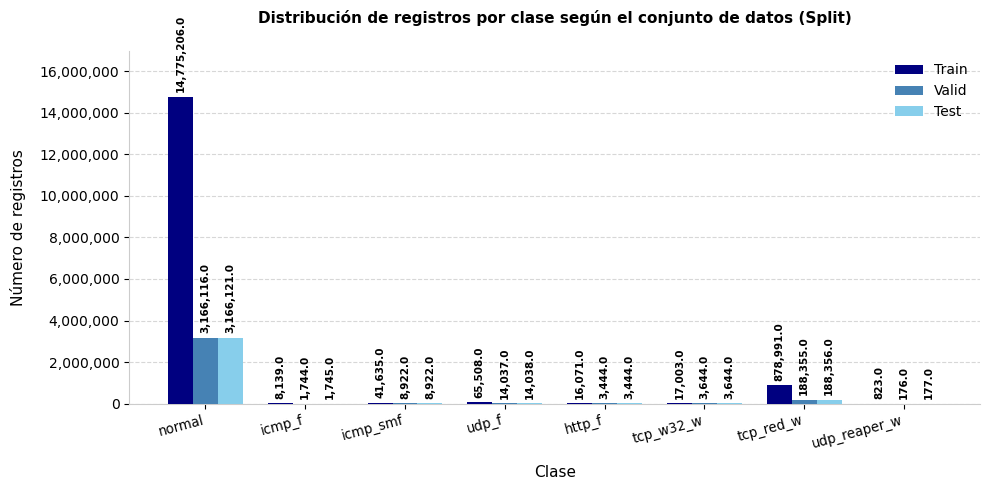

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURACIÓN DE ESTILO ESTÁNDAR TESIS ---
plt.rcParams["font.serif"] = ["Arial"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#cccccc"

# Ampliamos ligeramente el lienzo a 10 pulgadas de ancho por la cantidad de clases
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

# 1. Configuración de posiciones para barras agrupadas
clases = df_class_presence_validation["clase"]
x = np.arange(len(clases))  # Ubicaciones base para las etiquetas del eje X
width = 0.25  # Ancho de cada barra individual

# 2. Paleta de colores consistente (Gradiente / Tonos de Tesis)
colores = ["#000080", "#4682B4", "#87CEEB"]  # Azul Marino, Azul Acero, Azul Claro

# 3. Creación de los tres grupos de barras desplazadas
bars_train = ax.bar(
    x - width,
    df_class_presence_validation["n_train"],
    width,
    label="Train",
    color=colores[0],
    zorder=3,
)
bars_valid = ax.bar(
    x,
    df_class_presence_validation["n_valid"],
    width,
    label="Valid",
    color=colores[1],
    zorder=3,
)
bars_test = ax.bar(
    x + width,
    df_class_presence_validation["n_test"],
    width,
    label="Test",
    color=colores[2],
    zorder=3,
)

# 4. Títulos y etiquetas de los ejes
ax.set_title(
    "Distribución de registros por clase según el conjunto de datos (Split)",
    fontsize=11,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Clase", fontsize=11, labelpad=10)
ax.set_ylabel("Número de registros", fontsize=11, labelpad=10)

# Asignamos las etiquetas del eje X en el centro exacto de cada grupo
ax.set_xticks(x)
ax.set_xticklabels(clases, rotation=15, ha="right", fontsize=9.5)

# Calculamos el máximo global para dar el espacio libre arriba (15% extra)
max_val = max(
    df_class_presence_validation[["n_train", "n_valid", "n_test"]].max()
)
ax.set_ylim(0, max_val * 1.15)

# Formateador de miles en el eje Y
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda val, loc: f"{int(val):,}")
)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

# 5. Bordes (Spines) limpios estilo académico
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

# 6. Anotaciones de valores sobre cada barra
for bar_group in [bars_train, bars_valid, bars_test]:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Mostrar texto solo si hay datos
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + (max_val * 0.015),
                f"{height:,}",
                ha="center",
                va="bottom",
                fontsize=7.5,
                fontweight="semibold",
                rotation=90,  # Rotamos los números en vertical para evitar solapamiento entre los 3 grupos
            )

# Leyenda sobria y sin borde pesado
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

In [34]:
# Validación de estratos por dataset y clase
query_strata_split_validation = f"""
SELECT strata_key,
    SUM(CASE WHEN split = 'train' THEN 1 ELSE 0 END) AS n_train,
    SUM(CASE WHEN split = 'valid' THEN 1 ELSE 0 END) AS n_valid,
    SUM(CASE WHEN split = 'test' THEN 1 ELSE 0 END) AS n_test,
    COUNT(*) AS n_total
FROM read_parquet('{split_dataset_sql_path}')
GROUP BY strata_key
ORDER BY n_total ASC
"""
df_strata_split_validation = con.execute(query_strata_split_validation).df()
df_strata_split_validation

,strata_key,n_train,n_valid,n_test,n_total
0,REAPER_WORM_v2__udp_reaper_w,823.0,176.0,177.0,1176
1,ICMP_FLOOD_v2__icmp_f,8139.0,1744.0,1745.0,11628
2,HTTP_FLOOD_v2__http_f,16071.0,3444.0,3444.0,22959
3,BLASTER_WORM_v2__tcp_w32_w,17003.0,3644.0,3644.0,24291
4,ICMP_FLOOD_v2__icmp_smf,41635.0,8922.0,8922.0,59479
5,UDP_FLOOD_v2__udp_f,65508.0,14037.0,14038.0,93583
6,UDP_FLOOD_v2__normal,375578.0,80481.0,80482.0,536541
7,RED_WORM_v2__tcp_red_w,878991.0,188355.0,188356.0,1255702
8,BLASTER_WORM_v2__normal,2166630.0,464278.0,464279.0,3095187
9,HTTP_FLOOD_v2__normal,2860310.0,612924.0,612924.0,4086158


In [35]:
# Validación automática de estratos
strata_presence_errors = df_strata_split_validation[
    (df_strata_split_validation["n_train"] == 0)
    | (df_strata_split_validation["n_valid"] == 0)
    | (df_strata_split_validation["n_test"] == 0)
]
if not strata_presence_errors.empty:
    raise ValueError(
        "Hay estratos dataset-clase que no quedaron representados "
        "en todos los splits."
    )
print("Todos los estratos dataset-clase están representados en los tres splits.")

Todos los estratos dataset-clase están representados en los tres splits.


In [ ]:
# Guardar resúmenes del particionamiento
split_distribution_path = (PREPROCESSING_RESULTS_PATH / "split_distribucion_general.csv")
split_binary_distribution_path = (PREPROCESSING_RESULTS_PATH / "split_distribucion_binaria.csv")
split_class_distribution_path = (PREPROCESSING_RESULTS_PATH / "split_distribucion_por_clase.csv")
split_strata_validation_path = (PREPROCESSING_RESULTS_PATH / "split_validacion_estratos.csv")
df_split_distribution.to_csv(split_distribution_path, index=False, encoding="utf-8-sig")
df_split_binary_distribution.to_csv(split_binary_distribution_path, index=False, encoding="utf-8-sig")
df_split_class_distribution.to_csv(split_class_distribution_path, index=False, encoding="utf-8-sig")
df_strata_split_validation.to_csv(split_strata_validation_path, index=False, encoding="utf-8-sig")

print("Resúmenes de split guardados correctamente.")
print(split_distribution_path)
print(split_binary_distribution_path)
print(split_class_distribution_path)
print(split_strata_validation_path)

Se generó una única partición base del conjunto preparado en entrenamiento, validación y prueba, con proporciones aproximadas de 70 %, 15 % y 15 %, respectivamente. Para la tarea binaria se utilizarán registros normales y de ataque, mientras que para la clasificación del tipo de ataque se filtrarán únicamente los registros con `attack_a = 1`, conservando el mismo split.

La validación por estratos muestra que cada combinación dataset-clase quedó representada en las tres particiones, incluyendo la clase minoritaria udp_reaper_w, por tanto, el archivo `dataset_modelado_con_split.parquet` se considera la base común para los experimentos posteriores de modelado.

## 3. Muestra manejable única para experimentación

A partir del archivo con partición train/valid/test se construye una muestra de desarrollo única para los experimentos iniciales de modelado. Esta muestra conserva la misma estructura de particionamiento definida previamente y puede ser utilizada tanto para la tarea binaria de detección de ataques como para la clasificación del tipo de ataque, filtrando en este último caso únicamente los registros con `attack_a = 1`.

El muestreo se realiza de forma estratificada por `split` y `strata_key`, con el objetivo de conservar registros de todos los ataques y de todos los subconjuntos, pero limitando el predominio del tráfico normal y de la clase mayoritaria `tcp_red_w`. Esta etapa no corresponde a una técnica de balanceo supervisado; las estrategias como SMOTE, ADASYN o SMOTE+ENN se aplicarán posteriormente solo sobre el conjunto de entrenamiento dentro de los notebooks de modelado.

In [18]:
sample_dataset_path = (INTERIM_PATH / "dataset_modelado_dev.parquet")
sample_dataset_temp_path = (INTERIM_PATH / "dataset_modelado_dev_tmp.parquet")
if not split_dataset_path.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo con split: {split_dataset_path}"
    )
print("Archivo con split encontrado correctamente:")
print(split_dataset_path)

Archivo con split encontrado correctamente:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\data\interim\dataset_modelado_con_split.parquet


In [25]:
# Parámetros de muestreo manejable
# Tráfico normal: se toma un máximo por cada estrato normal dentro de cada split, como hay 6 subconjuntos normales, esto permite conservar diversidad de dataset sin usar millones de filas.
NORMAL_TRAIN_CAP_PER_STRATUM = 150_000
NORMAL_VALID_CAP_PER_STRATUM = 30_000
NORMAL_TEST_CAP_PER_STRATUM = 30_000

# Clase de ataque mayoritaria: se limita para que no domine completamente la muestra.
TCP_RED_TRAIN_CAP = 150_000
TCP_RED_VALID_CAP = 30_000
TCP_RED_TEST_CAP = 30_000

# Ataques minoritarios: El cap alto permite conservarlos completos.
MINORITY_ATTACK_CAP = 1_000_000
print("Parámetros de muestreo definidos.")

Parámetros de muestreo definidos.


**Train**:
- normales ≈ 900.000
- ataques ≈ 299.000

Total train ≈ 1.199.000

**Validación y Test**:
- normales ≈ 180.000
- ataques ≈ 61.967

Total valid ≈ 241.967

Total muestra ≈ 1.683.000 registros

In [26]:
# Construir plan de muestreo por split y estrato
query_available_strata = f"""
SELECT split, strata_key, clase, COUNT(*) AS n_disponible
FROM read_parquet('{split_dataset_sql_path}')
GROUP BY split, strata_key, clase
ORDER BY split, strata_key
"""
df_available_strata = con.execute(query_available_strata).df()
def get_sample_cap(split, clase):
    if clase == "normal":
        if split == "train":
            return NORMAL_TRAIN_CAP_PER_STRATUM
        elif split == "valid":
            return NORMAL_VALID_CAP_PER_STRATUM
        elif split == "test":
            return NORMAL_TEST_CAP_PER_STRATUM

    if clase == "tcp_red_w":
        if split == "train":
            return TCP_RED_TRAIN_CAP
        elif split == "valid":
            return TCP_RED_VALID_CAP
        elif split == "test":
            return TCP_RED_TEST_CAP

    return MINORITY_ATTACK_CAP

df_sample_plan = df_available_strata.copy()
df_sample_plan["sample_cap"] = df_sample_plan.apply(
    lambda row: get_sample_cap(split=row["split"], clase=row["clase"]), axis=1)

df_sample_plan["n_muestra_esperado"] = df_sample_plan[["n_disponible", "sample_cap"]].min(axis=1)
df_sample_plan

,split,strata_key,clase,n_disponible,sample_cap,n_muestra_esperado
0,test,BLASTER_WORM_v2__normal,normal,464279,30000,30000
1,test,BLASTER_WORM_v2__tcp_w32_w,tcp_w32_w,3644,1000000,3644
2,test,HTTP_FLOOD_v2__http_f,http_f,3444,1000000,3444
3,test,HTTP_FLOOD_v2__normal,normal,612924,30000,30000
4,test,ICMP_FLOOD_v2__icmp_f,icmp_f,1745,1000000,1745
5,test,ICMP_FLOOD_v2__icmp_smf,icmp_smf,8922,1000000,8922
6,test,ICMP_FLOOD_v2__normal,normal,650415,30000,30000
7,test,REAPER_WORM_v2__normal,normal,700779,30000,30000
8,test,REAPER_WORM_v2__udp_reaper_w,udp_reaper_w,177,1000000,177
9,test,RED_WORM_v2__normal,normal,657242,30000,30000


In [27]:
# Resumen esperado de la muestra
df_sample_expected_summary = (df_sample_plan
    .groupby("split", as_index=False)["n_muestra_esperado"]
    .sum()
)
df_sample_expected_summary["porcentaje"] = (100 * df_sample_expected_summary["n_muestra_esperado"] / df_sample_expected_summary["n_muestra_esperado"].sum())
df_sample_expected_summary

,split,n_muestra_esperado,porcentaje
0,test,241970,14.376312
1,train,1199179,71.247555
2,valid,241967,14.376133


In [28]:
df_sample_expected_by_class = (df_sample_plan
    .groupby(["split", "clase"], as_index=False)["n_muestra_esperado"]
    .sum()
)
df_sample_expected_by_class

,split,clase,n_muestra_esperado
0,test,http_f,3444
1,test,icmp_f,1745
2,test,icmp_smf,8922
3,test,normal,180000
4,test,tcp_red_w,30000
5,test,tcp_w32_w,3644
6,test,udp_f,14038
7,test,udp_reaper_w,177
8,train,http_f,16071
9,train,icmp_f,8139


In [31]:
# Crear muestra manejable única
import gc
import time
# Registrar el plan como tabla temporal en DuckDB
con.register("sample_plan", df_sample_plan[["split", "strata_key", "sample_cap"]])
sample_dataset_temp_sql_path = (sample_dataset_temp_path
    .resolve()
    .as_posix()
    .replace("'", "''")
)
# Columnas del archivo con split
split_file = pq.ParquetFile(split_dataset_path)
split_columns = split_file.schema_arrow.names
del split_file

def quote_identifier(column_name):
    return '"' + column_name.replace('"', '""') + '"'

split_columns_sql = ",\n        ".join(
    quote_identifier(col)
    for col in split_columns
)

if sample_dataset_temp_path.exists():
    sample_dataset_temp_path.unlink()

query_create_sample_dataset = f"""
COPY ( WITH ranked AS (
        SELECT d.*, p.sample_cap,
            ROW_NUMBER() OVER (PARTITION BY d.split, d.strata_key
                ORDER BY hash(CAST(d.row_id_model AS VARCHAR) || '_sample_{RANDOM_STATE}')
            ) AS rn
        FROM read_parquet('{split_dataset_sql_path}') AS d
        INNER JOIN sample_plan AS p
            ON d.split = p.split
            AND d.strata_key = p.strata_key
    )
    SELECT {split_columns_sql}
    FROM ranked
    WHERE rn <= sample_cap
)
TO '{sample_dataset_temp_sql_path}'
(FORMAT PARQUET, COMPRESSION 'snappy')
"""
con.execute(query_create_sample_dataset)
gc.collect()
time.sleep(1)
print("Archivo temporal de muestra creado:")
print(sample_dataset_temp_path)

Archivo temporal de muestra creado:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\data\interim\dataset_modelado_dev_tmp.parquet


In [32]:
# Validar y consolidar muestra manejable
sample_temp_metadata = pq.read_metadata(sample_dataset_temp_path)
sample_temp_rows = sample_temp_metadata.num_rows
sample_temp_columns = sample_temp_metadata.schema.names
del sample_temp_metadata
gc.collect()
time.sleep(1)
expected_sample_rows = int(df_sample_plan["n_muestra_esperado"].sum())
print(f"Filas esperadas en la muestra: {expected_sample_rows:,}")
print(f"Filas archivo temporal: {sample_temp_rows:,}")
print(f"Columnas archivo temporal: {len(sample_temp_columns)}")
if sample_temp_rows != expected_sample_rows:
    raise ValueError("El número de filas de la muestra no coincide con el esperado.")

if sample_dataset_path.exists():
    sample_dataset_path.unlink()

os.replace(sample_dataset_temp_path, sample_dataset_path)
print("Muestra manejable creada correctamente.")
print(f"Ruta: {sample_dataset_path}")

Filas esperadas en la muestra: 1,683,116
Filas archivo temporal: 1,683,116
Columnas archivo temporal: 30
Muestra manejable creada correctamente.
Ruta: C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\data\interim\dataset_modelado_dev.parquet


In [33]:
# Ruta SQL de la muestra
sample_dataset_sql_path = (sample_dataset_path
    .resolve()
    .as_posix()
    .replace("'", "''")
)
print(sample_dataset_sql_path)

C:/Users/Laura/Documents/TrabajoGrado2026/TG2026/data/interim/dataset_modelado_dev.parquet


Validaciones ->

In [34]:
# Distribución general de la muestra por split
query_sample_distribution = f"""
SELECT split, COUNT(*) AS n, 100.0 * COUNT(*) / SUM(COUNT(*)) OVER() AS porcentaje
FROM read_parquet('{sample_dataset_sql_path}')
GROUP BY split ORDER BY
    CASE split
        WHEN 'train' THEN 1
        WHEN 'valid' THEN 2
        WHEN 'test' THEN 3
        ELSE 4
    END
"""
df_sample_distribution = con.execute(query_sample_distribution).df()
df_sample_distribution

,split,n,porcentaje
0,train,1199179,71.247555
1,valid,241967,14.376133
2,test,241970,14.376312


In [35]:
# Distribución binaria en la muestra
query_sample_binary_distribution = f"""
SELECT split, attack_a, COUNT(*) AS n, 100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY split) AS porcentaje_en_split
FROM read_parquet('{sample_dataset_sql_path}')
GROUP BY split, attack_a
ORDER BY
    CASE split
        WHEN 'train' THEN 1
        WHEN 'valid' THEN 2
        WHEN 'test' THEN 3
        ELSE 4
    END,
    attack_a
"""
df_sample_binary_distribution = con.execute(query_sample_binary_distribution).df()
df_sample_binary_distribution

,split,attack_a,n,porcentaje_en_split
0,train,0,900000,75.051348
1,train,1,299179,24.948652
2,valid,0,180000,74.390309
3,valid,1,61967,25.609691
4,test,0,180000,74.389387
5,test,1,61970,25.610613


In [36]:
# Distribución por clase en la muestra
query_sample_class_distribution = f"""
SELECT split, clase, COUNT(*) AS n, 100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY split) AS porcentaje_en_split
FROM read_parquet('{sample_dataset_sql_path}')
GROUP BY split, clase
ORDER BY
    CASE split
        WHEN 'train' THEN 1
        WHEN 'valid' THEN 2
        WHEN 'test' THEN 3
        ELSE 4
    END,
    CASE clase
        WHEN 'normal' THEN 1
        WHEN 'icmp_f' THEN 2
        WHEN 'icmp_smf' THEN 3
        WHEN 'udp_f' THEN 4
        WHEN 'http_f' THEN 5
        WHEN 'tcp_w32_w' THEN 6
        WHEN 'tcp_red_w' THEN 7
        WHEN 'udp_reaper_w' THEN 8
        ELSE 9
    END
"""
df_sample_class_distribution = con.execute(query_sample_class_distribution).df()
df_sample_class_distribution

,split,clase,n,porcentaje_en_split
0,train,normal,900000,75.051348
1,train,icmp_f,8139,0.678714
2,train,icmp_smf,41635,3.471959
3,train,udp_f,65508,5.462737
4,train,http_f,16071,1.340167
5,train,tcp_w32_w,17003,1.417887
6,train,tcp_red_w,150000,12.508558
7,train,udp_reaper_w,823,0.068630
8,valid,normal,180000,74.390309
9,valid,icmp_f,1744,0.720759


In [37]:
# Validación de presencia de clases en la muestra
query_sample_class_presence = f"""
SELECT clase,
    SUM(CASE WHEN split = 'train' THEN 1 ELSE 0 END) AS n_train,
    SUM(CASE WHEN split = 'valid' THEN 1 ELSE 0 END) AS n_valid,
    SUM(CASE WHEN split = 'test' THEN 1 ELSE 0 END) AS n_test
FROM read_parquet('{sample_dataset_sql_path}')
GROUP BY clase ORDER BY
    CASE clase
        WHEN 'normal' THEN 1
        WHEN 'icmp_f' THEN 2
        WHEN 'icmp_smf' THEN 3
        WHEN 'udp_f' THEN 4
        WHEN 'http_f' THEN 5
        WHEN 'tcp_w32_w' THEN 6
        WHEN 'tcp_red_w' THEN 7
        WHEN 'udp_reaper_w' THEN 8
        ELSE 9
    END
"""
df_sample_class_presence = con.execute(query_sample_class_presence).df()
df_sample_class_presence

,clase,n_train,n_valid,n_test
0,normal,900000.0,180000.0,180000.0
1,icmp_f,8139.0,1744.0,1745.0
2,icmp_smf,41635.0,8922.0,8922.0
3,udp_f,65508.0,14037.0,14038.0
4,http_f,16071.0,3444.0,3444.0
5,tcp_w32_w,17003.0,3644.0,3644.0
6,tcp_red_w,150000.0,30000.0,30000.0
7,udp_reaper_w,823.0,176.0,177.0


In [38]:
# Validación automática de presencia de clases
sample_class_presence_errors = df_sample_class_presence[(df_sample_class_presence["n_train"] == 0)
    | (df_sample_class_presence["n_valid"] == 0)
    | (df_sample_class_presence["n_test"] == 0)
]
if not sample_class_presence_errors.empty:
    raise ValueError("Hay clases que no quedaron representadas en todos los splits de la muestra.")
print("Todas las clases están representadas en train, validación y test dentro de la muestra.")

Todas las clases están representadas en train, validación y test dentro de la muestra.


In [ ]:
# ======== NO EJECUTADO ==========
# Guardar resúmenes de la muestra
sample_plan_path = (PREPROCESSING_RESULTS_PATH / "muestra_dev_plan.csv")
sample_distribution_path = (PREPROCESSING_RESULTS_PATH / "muestra_dev_distribucion_general.csv")
sample_binary_distribution_path = (PREPROCESSING_RESULTS_PATH / "muestra_dev_distribucion_binaria.csv")
sample_class_distribution_path = (PREPROCESSING_RESULTS_PATH / "muestra_dev_distribucion_por_clase.csv")
sample_class_presence_path = (PREPROCESSING_RESULTS_PATH / "muestra_dev_presencia_clases.csv")
df_sample_plan.to_csv(sample_plan_path, index=False, encoding="utf-8-sig")
df_sample_distribution.to_csv(sample_distribution_path, index=False, encoding="utf-8-sig")
df_sample_binary_distribution.to_csv(sample_binary_distribution_path, index=False, encoding="utf-8-sig")
df_sample_class_distribution.to_csv(sample_class_distribution_path, index=False, encoding="utf-8-sig")
df_sample_class_presence.to_csv(sample_class_presence_path, index=False, encoding="utf-8-sig")
print("Resúmenes de la muestra guardados correctamente.")
print(sample_plan_path)
print(sample_distribution_path)
print(sample_binary_distribution_path)
print(sample_class_distribution_path)
print(sample_class_presence_path)

El muestreo se realizó de forma estratificada por `split` y `strata_key`. Se conservaron completamente los ataques minoritarios y se limitó la cantidad de registros de tráfico normal y de la clase mayoritaria `tcp_red_w`, con el fin de obtener una base computacionalmente manejable sin perder representación de las clases minoritarias. Esta muestra no reemplaza al conjunto completo particionado, **será utilizada para el desarrollo y prueba inicial de los pipelines de modelado**.

## 4. Funciones de preprocesamiento

En esta sección se definen funciones reutilizables para transformar las variables predictoras antes del modelado. Estas transformaciones no se aplican de manera permanente sobre el archivo Parquet, sino dentro de los pipelines de entrenamiento, de esta forma, los transformadores se ajustan únicamente con el conjunto de entrenamiento y luego se aplican a validación y prueba, evitando fuga de información.

Las variables numéricas de volumen (`td`, `ipkt`, `ibyt`) podrán transformarse mediante `log1p` y escalarse según el modelo. Las variables categóricas de baja cardinalidad se codificarán mediante one-hot encoding. Las variables de media y alta cardinalidad, como IP, puertos, sistemas autónomos e interfaces, se tratarán mediante codificaciones compactas para evitar matrices excesivamente grandes.

In [19]:
# Funciones de preprocesamiento
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [20]:
# OneHotEncoder compatible con distintas versiones de sklearn
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)

### 4.1 Transformación log1p

Esta función se aplicará a td, ipkt e ibyt.

In [34]:
# Transformación log1p para variables sesgadas
def safe_log1p_array(X):
    """
    Aplica log1p a variables numéricas no negativas.
    Se usa np.maximum para evitar errores si aparece algún valor negativo inesperado.
    """
    X = np.asarray(X, dtype=np.float32)
    X = np.maximum(X, 0)
    return np.log1p(X).astype(np.float32)

### 4.2 Codificación por frecuencia

Sirve para variables de media y alta cardinalidad. La idea es reemplazar cada categoría por su frecuencia relativa aprendida en train. 

-> Por ejemplo, si una IP aparece mucho en entrenamiento, se codifica con una frecuencia más alta; si aparece en validación/test pero no apareció en entrenamiento, se codifica como 0.

In [ ]:
"""
# Codificador por frecuencia
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    # Codifica variables categóricas usando frecuencia relativa aprendida en train. Categorías no vistas en validación/test se codifican como 0.
    def __init__(self, columns=None, suffix="_freq"):
        self.columns = columns
        self.suffix = suffix

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        if self.columns is None:
            self.columns_ = X.columns.tolist()
        else:
            self.columns_ = list(self.columns)

        self.frequency_maps_ = {}
        for col in self.columns_:
            values = X[col].astype("string").fillna("__MISSING__")
            freq = values.value_counts(normalize=True)
            self.frequency_maps_[col] = freq.to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        output = pd.DataFrame(index=X.index)
        for col in self.columns_:
            values = X[col].astype("string").fillna("__MISSING__")
            output[f"{col}{self.suffix}"] = (values
                .map(self.frequency_maps_[col])
                .fillna(0)
                .astype(np.float32)
            )
        return output

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{col}{self.suffix}" for col in self.columns_], dtype=object)
"""

### 4.3 Codificación controlada de IP

Para `sa` y `da` no se hace one-hot completo, porque tienen millones de valores únicos. En cambio, se usa una representación compacta, comprendida por la frecuencia de la IP exacta, frecuencia del prefijo e indicador de IPv6.

In [36]:
# Codificador compacto de direcciones IP
class IPFeatureEncoder(BaseEstimator, TransformerMixin):
    """
    Codificación compacta para columnas IP.
    Para cada IP genera:
    - frecuencia de la IP exacta en train
    - frecuencia del prefijo en train
    - indicador de IPv6
    """
    def __init__(self, columns=None, prefix_suffix="_prefix_freq", ip_suffix="_ip_freq"):
        self.columns = columns
        self.prefix_suffix = prefix_suffix
        self.ip_suffix = ip_suffix

    def _get_prefix(self, series):
        s = series.astype("string").fillna("__MISSING__")
        is_ipv6 = s.str.contains(":", regex=False, na=False)
        prefix = pd.Series("__UNKNOWN__", index=s.index, dtype="string")

        # IPv4: primeros tres octetos como prefijo aproximado /24
        ipv4_values = s[~is_ipv6]
        ipv4_prefix = ipv4_values.str.extract(r"^(\d+\.\d+\.\d+)", expand=False).fillna("__UNKNOWN__")
        prefix.loc[~is_ipv6] = ipv4_prefix

        # IPv6: primeros cuatro bloques como prefijo compacto
        ipv6_values = s[is_ipv6]
        ipv6_prefix = (ipv6_values
            .str.split(":")
            .str[:4]
            .str.join(":")
            .fillna("__UNKNOWN__")
        )
        prefix.loc[is_ipv6] = ipv6_prefix
        return prefix.astype("string")

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        if self.columns is None:
            self.columns_ = X.columns.tolist()
        else:
            self.columns_ = list(self.columns)

        self.ip_frequency_maps_ = {}
        self.prefix_frequency_maps_ = {}
        for col in self.columns_:
            values = X[col].astype("string").fillna("__MISSING__")
            prefixes = self._get_prefix(values)
            self.ip_frequency_maps_[col] = (values
                .value_counts(normalize=True)
                .to_dict()
            )
            self.prefix_frequency_maps_[col] = (prefixes
                .value_counts(normalize=True)
                .to_dict()
            )
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        output = pd.DataFrame(index=X.index)
        for col in self.columns_:
            values = X[col].astype("string").fillna("__MISSING__")
            prefixes = self._get_prefix(values)
            is_ipv6 = values.str.contains(":", regex=False, na=False)
            output[f"{col}{self.ip_suffix}"] = (values
                .map(self.ip_frequency_maps_[col])
                .fillna(0)
                .astype(np.float32)
            )
            output[f"{col}{self.prefix_suffix}"] = (prefixes
                .map(self.prefix_frequency_maps_[col])
                .fillna(0)
                .astype(np.float32)
            )
            output[f"{col}_is_ipv6"] = (is_ipv6.astype(np.int8))
        return output

    def get_feature_names_out(self, input_features=None):
        names = []
        for col in self.columns_:
            names.extend([
                f"{col}{self.ip_suffix}",
                f"{col}{self.prefix_suffix}",
                f"{col}_is_ipv6",
            ])
        return np.array(names, dtype=object)

### 4.4 Codificación compacta de puertos

Los puertos `sp` y `dp` no se tratan como variables continuas, además de la frecuencia, se agrega indicadores simples para distinguir puertos bien conocidos, registrados y dinámicos.

In [37]:
# Codificador compacto de puertos
class PortFeatureEncoder(BaseEstimator, TransformerMixin):
    """
    Genera variables binarias simples para columnas de puertos:
    - puerto cero
    - puerto bien conocido: 1-1023
    - puerto registrado: 1024-49151
    - puerto dinámico/efímero: 49152-65535
    """
    def __init__(self, columns=None):
        self.columns = columns

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        if self.columns is None:
            self.columns_ = X.columns.tolist()
        else:
            self.columns_ = list(self.columns)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        output = pd.DataFrame(index=X.index)
        for col in self.columns_:
            values = pd.to_numeric(X[col], errors="coerce").fillna(-1)
            output[f"{col}_is_zero"] = (values.eq(0).astype(np.int8))
            output[f"{col}_is_well_known"] = (values.between(1, 1023).astype(np.int8))
            output[f"{col}_is_registered"] = (values.between(1024, 49151).astype(np.int8))
            output[f"{col}_is_dynamic"] = (values.between(49152, 65535).astype(np.int8))
        return output
    
    def get_feature_names_out(self, input_features=None):
        names = []
        for col in self.columns_:
            names.extend([
                f"{col}_is_zero",
                f"{col}_is_well_known",
                f"{col}_is_registered",
                f"{col}_is_dynamic",
            ])
        return np.array(names, dtype=object)

### Definir columnas para cada tratamiento

In [21]:
# Columnas por tipo de transformación
ip_columns = ["sa", "da"]
port_feature_columns = ["sp", "dp"]
frequency_encoding_columns = ["sp", "dp", "sas", "das", "stos", "in_if", "out_if"]
one_hot_columns = low_cardinality_categorical_columns
numeric_log_columns = log_transform_columns
numeric_passthrough_columns = [
    col
    for col in numeric_continuous_columns
    if col not in numeric_log_columns
]
print("Columnas con log1p:")
print(numeric_log_columns)
print("\nColumnas one-hot:")
print(one_hot_columns)
print("\nColumnas por frecuencia:")
print(frequency_encoding_columns)
print("\nColumnas IP:")
print(ip_columns)
print("\nColumnas de puertos:")
print(port_feature_columns)
print("\nBanderas binarias:")
print(binary_flag_columns)

Columnas con log1p:
['td', 'ipkt', 'ibyt']

Columnas one-hot:
['pr', 'exp']

Columnas por frecuencia:
['sp', 'dp', 'sas', 'das', 'stos', 'in_if', 'out_if']

Columnas IP:
['sa', 'da']

Columnas de puertos:
['sp', 'dp']

Banderas binarias:
['tcp_flag_fin', 'tcp_flag_syn', 'tcp_flag_rst', 'tcp_flag_psh', 'tcp_flag_ack', 'tcp_flag_urg', 'tcp_flag_ece', 'tcp_flag_cwr']


In [22]:
# Validación de columnas del preprocesamiento
preprocessing_input_columns = sorted(set(numeric_log_columns + numeric_passthrough_columns + binary_flag_columns + one_hot_columns
        + frequency_encoding_columns + ip_columns + port_feature_columns))

missing_preprocessing_columns = sorted(set(preprocessing_input_columns) - set(predictor_candidate_columns))
if missing_preprocessing_columns:
    raise ValueError(
        f"Hay columnas de preprocesamiento que no son predictoras: "
        f"{missing_preprocessing_columns}"
    )
print("Columnas de preprocesamiento validadas correctamente.")

Columnas de preprocesamiento validadas correctamente.


### Constructor del preprocesador base

- linear / ae / isolation_forest: log1p + escalamiento de variables numéricas.
- xgboost: log1p opcional, sin escalamiento obligatorio.

In [40]:
# Constructor de preprocesador base
def build_base_preprocessor(model_family="linear"):
    """
    Construye un preprocesador compacto para los modelos.
    model_family:
        - "linear": Regresión Logística
        - "ae": Autoencoder + Regresión Logística
        - "isolation_forest": Isolation Forest
        - "xgboost": XGBoost
    El preprocesador:
        - aplica log1p a td, ipkt, ibyt
        - escala numéricas cuando aplica
        - codifica pr y exp con one-hot
        - codifica variables de media/alta cardinalidad por frecuencia
        - codifica IP de forma compacta
        - agrega variables compactas de puertos
        - conserva banderas TCP binarias como 0/1
    """
    valid_model_families = {"linear", "ae", "isolation_forest", "xgboost"}
    if model_family not in valid_model_families:
        raise ValueError(f"model_family debe estar en {valid_model_families}")
    
    scale_numeric = model_family in {"linear", "ae", "isolation_forest"}

    if scale_numeric:
        numeric_log_pipeline = Pipeline(
            steps=[("imputer", SimpleImputer(strategy="median")),
                ("log1p", FunctionTransformer(safe_log1p_array, validate=False, feature_names_out="one-to-one")),
                ("scaler", StandardScaler()),
            ]
        )
    else:
        numeric_log_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("log1p", FunctionTransformer(safe_log1p_array, validate=False, feature_names_out="one-to-one"
                )),
            ]
        )

    one_hot_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_one_hot_encoder())])
    preprocessor = ColumnTransformer(
        transformers=[
            ("num_log", numeric_log_pipeline, numeric_log_columns),
            ("flags", "passthrough", binary_flag_columns),
            ("onehot", one_hot_pipeline, one_hot_columns),
            ("frequency", FrequencyEncoder(columns=frequency_encoding_columns), frequency_encoding_columns),
            ("ip_features", IPFeatureEncoder(columns=ip_columns), ip_columns),
            ("port_features", PortFeatureEncoder(columns=port_feature_columns), port_feature_columns),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )
    return preprocessor

In [41]:
# Función para obtener nombres de variables transformadas
def get_transformed_feature_names(preprocessor):
    """
    Intenta recuperar los nombres de las variables generadas por el preprocesador, requiere que el preprocesador ya haya sido ajustado con fit.
    """
    try:
        return preprocessor.get_feature_names_out()
    except Exception as error:
        print("No fue posible obtener los nombres de variables transformadas.")
        print(error)
        return None

In [45]:
# Funciones para cargar datos por split - (cargan los datos desde la muestra de desarrollo o desde el dataset completo con split)
def quote_identifier(column_name):
    return '"' + column_name.replace('"', '""') + '"'

def get_modeling_dataset_path(use_dev_sample=True):
    """
    Retorna la ruta del dataset a usar:
    - muestra de desarrollo, si use_dev_sample=True
    - dataset completo con split, si use_dev_sample=False
    """
    if use_dev_sample:
        return sample_dataset_path

    return split_dataset_path

def get_modeling_sql_path(use_dev_sample=True):
    dataset_path = get_modeling_dataset_path(use_dev_sample=use_dev_sample)
    if not dataset_path.exists():
        raise FileNotFoundError(f"No existe el dataset solicitado: {dataset_path}")

    return (dataset_path
        .resolve()
        .as_posix()
        .replace("'", "''")
    )

def load_split_dataframe(split_name, use_dev_sample=True, columns=None, limit=None):
    """
    Carga en pandas un split específico.
    split_name: "train", "valid" o "test"
    use_dev_sample:
        True  -> usa dataset_modelado_dev.parquet
        False -> usa dataset_modelado_con_split.parquet
    columns: lista opcional de columnas a cargar.
    limit: límite opcional de filas, útil para pruebas rápidas.
    """
    if split_name not in {"train", "valid", "test"}:
        raise ValueError("split_name debe ser 'train', 'valid' o 'test'.")

    dataset_sql_path = get_modeling_sql_path(use_dev_sample=use_dev_sample)
    if columns is None:
        columns = (predictor_candidate_columns + target_columns + auxiliary_columns + ["clase", "strata_key", "split", "row_id_model"])

    columns_sql = ",\n        ".join(
        quote_identifier(col)
        for col in columns
    )
    limit_sql = ""
    if limit is not None:
        limit_sql = f"\nLIMIT {int(limit)}"

    query = f"""
    SELECT {columns_sql}
    FROM read_parquet('{dataset_sql_path}')
    WHERE split = '{split_name}'
    {limit_sql}
    """
    return con.execute(query).df()

In [43]:
# Separar X e y según tarea
def split_features_target(df, task="binary"):
    """
    Separa variables predictoras y variable objetivo.
    task:
        - "binary": usa attack_a como objetivo
        - "multiclass": filtra attack_a = 1 y usa attack_t como objetivo
    """
    if task not in {"binary", "multiclass"}:
        raise ValueError("task debe ser 'binary' o 'multiclass'.")
    
    df_task = df.copy()
    if task == "binary":
        X = df_task[predictor_candidate_columns].copy()
        y = df_task[binary_target_column].copy()
    else:
        df_task = df_task[df_task[binary_target_column] == 1].copy()
        X = df_task[predictor_candidate_columns].copy()
        y = df_task[multiclass_target_column].copy()
    return X, y

In [46]:
# Prueba rápida del preprocesador
df_train_debug = load_split_dataframe(split_name="train", use_dev_sample=True, limit=10_000)
X_train_debug, y_train_debug = split_features_target(df_train_debug, task="binary")
preprocessor_debug = build_base_preprocessor(model_family="linear")
X_train_debug_transformed = preprocessor_debug.fit_transform(X_train_debug, y_train_debug)
print("Forma original:")
print(X_train_debug.shape)
print("\nForma transformada:")
print(X_train_debug_transformed.shape)
print("\nTipo de matriz transformada:")
print(type(X_train_debug_transformed))

Forma original:
(10000, 22)

Forma transformada:
(10000, 39)

Tipo de matriz transformada:
<class 'numpy.ndarray'>


In [52]:
# Revisión de nombres de variables transformadas
debug_feature_names = get_transformed_feature_names(preprocessor_debug)
if debug_feature_names is not None:
    print(f"Número de variables transformadas: {len(debug_feature_names)}")
    debug_feature_names[:30]

Número de variables transformadas: 39


In [53]:
# ============================================================
# Guardar configuración base de preprocesamiento
preprocessing_config = {
    "numeric_log_columns": numeric_log_columns,
    "binary_flag_columns": binary_flag_columns,
    "one_hot_columns": one_hot_columns,
    "frequency_encoding_columns": frequency_encoding_columns,
    "ip_columns": ip_columns,
    "port_feature_columns": port_feature_columns,
    "target_columns": target_columns,
    "auxiliary_columns": auxiliary_columns,
    "predictor_candidate_columns": predictor_candidate_columns,
    "binary_target_column": binary_target_column,
    "multiclass_target_column": multiclass_target_column,
}
preprocessing_config_path = (PREPROCESSING_RESULTS_PATH / "preprocessing_config.json")
with open(preprocessing_config_path, "w", encoding="utf-8") as file:
    json.dump(preprocessing_config, file, indent=4, ensure_ascii=False)

print("Configuración de preprocesamiento guardada en:")
print(preprocessing_config_path)

Configuración de preprocesamiento guardada en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\preprocessing\preprocessing_config.json


In [25]:
# Cargar utilidades reutilizables desde src/
import sys
import importlib
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.modeling_utils as modeling_utils
# Importante en Jupyter: si se volvió a escribir modeling_utils.py, reload carga la versión más reciente.
importlib.reload(modeling_utils)
from src.modeling_utils import (
    FrequencyEncoder,
    IPFeatureEncoder,
    PortFeatureEncoder,
    build_base_preprocessor,
    get_transformed_feature_names,
    load_split_dataframe,
    split_features_target,
    compute_class_weight_dict,
    compute_binary_scale_pos_weight,
    make_binary_sampling_strategy,
    make_multiclass_sampling_strategy,
    build_resampler,
    validate_imbalance_strategy_for_model,
    summarize_class_distribution,
)
print("Utilidades de modelado cargadas correctamente.")

Utilidades de modelado cargadas correctamente.


In [28]:
# Revisión de nombres de variables transformadas

debug_feature_names = (
    get_transformed_feature_names(
        preprocessor_debug
    )
)

if debug_feature_names is not None:

    print(
        "Número de variables transformadas: "
        f"{len(debug_feature_names)}"
    )

    display(
        debug_feature_names[:30]
    )

Número de variables transformadas: 39


array(['num_log__td', 'num_log__ipkt', 'num_log__ibyt',
       'flags__tcp_flag_fin', 'flags__tcp_flag_syn',
       'flags__tcp_flag_rst', 'flags__tcp_flag_psh',
       'flags__tcp_flag_ack', 'flags__tcp_flag_urg',
       'flags__tcp_flag_ece', 'flags__tcp_flag_cwr', 'onehot__pr_ICMP',
       'onehot__pr_ICMP6', 'onehot__pr_IPv6', 'onehot__pr_TCP',
       'onehot__pr_UDP', 'onehot__exp_1', 'onehot__exp_2',
       'frequency__sp_freq', 'frequency__dp_freq', 'frequency__sas_freq',
       'frequency__das_freq', 'frequency__stos_freq',
       'frequency__in_if_freq', 'frequency__out_if_freq',
       'ip_features__sa_ip_freq', 'ip_features__sa_prefix_freq',
       'ip_features__sa_is_ipv6', 'ip_features__da_ip_freq',
       'ip_features__da_prefix_freq'], dtype=object)

## 5. Definición de estrategias de desbalanceo

En esta sección se definen las estrategias que serán utilizadas posteriormente en los notebooks de modelado para analizar el efecto del desbalance de clases. Estas estrategias no se aplican directamente en este notebook, sino que se dejan configuradas para garantizar consistencia entre los modelos supervisados.

Las técnicas consideradas son: entrenamiento sin remuestreo, ajuste mediante pesos de clase, SMOTE, ADASYN y SMOTE+ENN. Las técnicas de remuestreo se aplicarán únicamente sobre el conjunto de entrenamiento, después del preprocesamiento de las variables predictoras, y nunca sobre validación o prueba. Para Isolation Forest no se aplicarán estas estrategias, dado que corresponde a un enfoque no supervisado de detección de anomalías.

In [22]:
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
try:
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.combine import SMOTEENN
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True

except ImportError:
    IMBLEARN_AVAILABLE = False
    print("No se encontró imbalanced-learn. Para usar SMOTE, ADASYN o SMOTE+ENN instala el paquete con:")
    print("pip install imbalanced-learn")

In [9]:
# Estrategias generales de desbalance
IMBALANCE_STRATEGIES = ["none", "class_weight", "smote", "adasyn", "smote_enn"]
imbalance_strategy_descriptions = {
    "none": "Sin remuestreo ni pesos de clase",
    "class_weight": "Ajuste algorítmico mediante pesos de clase",
    "smote": "Sobremuestreo sintético de la clase minoritaria",
    "adasyn": "Sobremuestreo sintético adaptativo",
    "smote_enn": "SMOTE seguido de limpieza con Edited Nearest Neighbours",
}
df_imbalance_strategies = pd.DataFrame([
    {
        "Estrategia": strategy,
        "Descripcion": imbalance_strategy_descriptions[strategy],
    }
    for strategy in IMBALANCE_STRATEGIES
])
df_imbalance_strategies

,Estrategia,Descripcion
0,none,Sin remuestreo ni pesos de clase
1,class_weight,Ajuste algorítmico mediante pesos de clase
2,smote,Sobremuestreo sintético de la clase minoritaria
3,adasyn,Sobremuestreo sintético adaptativo
4,smote_enn,SMOTE seguido de limpieza con Edited Nearest N...


In [ ]:
# Parámetros controlados de remuestreo - Perfil conservador utilizado inicialmente

# Para tarea binaria: Después del remuestreo, se busca que la clase minoritaria tenga como máximo el 50 % del tamaño de la clase mayoritaria.
BINARY_CONSERVATIVE_RATIO_UPPER_BOUND = 0.50
# La clase minoritaria no podrá crecer a más de 1.5 veces su tamaño original.
BINARY_CONSERVATIVE_MAX_MINORITY_MULTIPLIER = 1.50
# Máximo absoluto de observaciones sintéticas añadidas que SMOTE/ADASYN podrían considerar.
BINARY_CONSERVATIVE_MAX_SYNTHETIC_SAMPLES = 150_000


# Perfil moderado: objetivo aproximado de 15 % de ataques
BINARY_MODERATE_TARGET_PREVALENCE = 0.15
BINARY_MODERATE_RATIO_UPPER_BOUND = (
    BINARY_MODERATE_TARGET_PREVALENCE
    / (1 - BINARY_MODERATE_TARGET_PREVALENCE)
)
BINARY_MODERATE_MAX_MINORITY_MULTIPLIER = 2.54
BINARY_MODERATE_MAX_SYNTHETIC_SAMPLES = 1_585_000


# Para tarea multiclase: Las clases con menos de este número de registros en train se sobremuestrean hasta este valor. Las clases que ya superan este valor no se modifican.
MULTICLASS_TARGET_COUNT_UPPER_BOUND = 50_000
MULTICLASS_MAX_CLASS_MULTIPLIER = 1.50
MULTICLASS_MAX_SYNTHETIC_PER_CLASS = 20_000

SMOTE_K_NEIGHBORS = 5
ADASYN_N_NEIGHBORS = 5
print("Parámetros de desbalance definidos.")
print("Ratio moderate:", BINARY_MODERATE_RATIO_UPPER_BOUND)

Parámetros de desbalance definidos.
Ratio moderate: 0.17647058823529413


In [16]:
# Guardar configuración de estrategias de desbalance
imbalance_config = {
    "imbalance_strategies": IMBALANCE_STRATEGIES,
    "binary_oversampling_profiles": {
        "conservative": {
            "target_prevalence_approx": 0.0739,
            "ratio_upper_bound": BINARY_CONSERVATIVE_RATIO_UPPER_BOUND,
            "max_minority_multiplier": BINARY_CONSERVATIVE_MAX_MINORITY_MULTIPLIER,
            "max_synthetic_samples": BINARY_CONSERVATIVE_MAX_SYNTHETIC_SAMPLES,
        },

        "moderate": {
            "target_prevalence_approx": BINARY_MODERATE_TARGET_PREVALENCE,
            "ratio_upper_bound": BINARY_MODERATE_RATIO_UPPER_BOUND,
            "max_minority_multiplier": BINARY_MODERATE_MAX_MINORITY_MULTIPLIER,
            "max_synthetic_samples": BINARY_MODERATE_MAX_SYNTHETIC_SAMPLES,
        },
    },
    "multiclass_oversampling_policy": "bounded",
    "multiclass_target_count_upper_bound": MULTICLASS_TARGET_COUNT_UPPER_BOUND,
    "multiclass_max_class_multiplier": MULTICLASS_MAX_CLASS_MULTIPLIER,
    "multiclass_max_synthetic_per_class": MULTICLASS_MAX_SYNTHETIC_PER_CLASS,
    "smote_k_neighbors": SMOTE_K_NEIGHBORS,
    "adasyn_n_neighbors": ADASYN_N_NEIGHBORS,
    "validation_test_resampling": False,
    "isolation_forest_note": ("SMOTE, ADASYN, SMOTE+ENN y class_weight no aplican a Isolation Forest en este protocolo."),
}
imbalance_config_path = (PREPROCESSING_RESULTS_PATH / "imbalance_config.json")
imbalance_strategies_path = (PREPROCESSING_RESULTS_PATH / "estrategias_desbalance.csv")
with open(imbalance_config_path, "w", encoding="utf-8") as file:
    json.dump(imbalance_config, file, indent=4, ensure_ascii=False)

df_imbalance_strategies.to_csv(imbalance_strategies_path, index=False, encoding="utf-8-sig")
print("Configuración de desbalance guardada en:")
print(imbalance_config_path)
print("\nTabla de estrategias guardada en:")
print(imbalance_strategies_path)

Configuración de desbalance guardada en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\preprocessing\imbalance_config.json

Tabla de estrategias guardada en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\preprocessing\estrategias_desbalance.csv


### Funciones para pesos de clase

In [28]:
# Cálculo de pesos de clase
def compute_class_weight_dict(y):
    """
    Calcula pesos de clase balanceados para modelos de sklearn, como Regresión Logística.
    """
    y_array = np.asarray(y)
    classes = np.unique(y_array)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_array)
    return dict(zip(classes, weights))

def compute_binary_scale_pos_weight(y, positive_label=1):
    """
    Calcula scale_pos_weight para XGBoost en clasificación binaria -> scale_pos_weight = negativos / positivos
    """
    counts = pd.Series(y).value_counts()
    n_positive = counts.get(positive_label, 0)
    n_negative = counts.drop(labels=[positive_label], errors="ignore").sum()

    if n_positive == 0:
        raise ValueError("No hay registros positivos para calcular scale_pos_weight.")

    return n_negative / n_positive

### Estrategias de muestreo

In [ ]:
# Estrategia de remuestreo para clasificación binaria - modificada en modeling_utils.py
def make_binary_sampling_strategy(y, target_ratio=BINARY_OVERSAMPLING_RATIO_UPPER_BOUND, positive_label=1):
    """
    target_ratio representa:
        n_minority_after_resampling / n_majority
    Si la proporción actual ya es igual o superior al objetivo, no se aplica remuestreo.
    """
    counts = pd.Series(y).value_counts()
    n_positive = counts.get(positive_label, 0)
    n_negative = counts.drop(labels=[positive_label], errors="ignore").sum()

    if n_positive == 0 or n_negative == 0:
        raise ValueError("La tarea binaria requiere presencia de ambas clases")

    current_ratio = n_positive / n_negative

    if current_ratio >= target_ratio:
        return None

    return target_ratio

In [30]:
# Estrategia de remuestreo para clasificación multiclase
def make_multiclass_sampling_strategy(y, target_min_count=MULTICLASS_TARGET_MIN_COUNT):
    """
    Las clases con menos de target_min_count registros se aumentan hasta ese valor. Las clases que ya tienen más registros no se modifican.
    """
    counts = pd.Series(y).value_counts()
    sampling_strategy = {}
    for class_label, count in counts.items():
        if count < target_min_count:
            sampling_strategy[class_label] = target_min_count

    if len(sampling_strategy) == 0:
        return None

    return sampling_strategy

### Constructor de remuestreador

In [31]:
# Constructor de remuestreador
def build_resampler(strategy_name, task, y_train, random_state=RANDOM_STATE):
    """
    Construye el objeto de remuestreo para una estrategia dada.
    strategy_name:
        - "none"
        - "class_weight"
        - "smote"
        - "adasyn"
        - "smote_enn"
    task:
        - "binary"
        - "multiclass"
    Nota: "none" y "class_weight" no devuelven remuestreador, porque no modifican los datos.
    """
    if strategy_name not in IMBALANCE_STRATEGIES:
        raise ValueError(f"Estrategia no válida: {strategy_name}")

    if task not in {"binary", "multiclass"}:
        raise ValueError("task debe ser 'binary' o 'multiclass'.")

    if strategy_name in {"none", "class_weight"}:
        return None

    if not IMBLEARN_AVAILABLE:
        raise ImportError("imbalanced-learn no está disponible.")

    if task == "binary":
        sampling_strategy = make_binary_sampling_strategy(y=y_train, target_ratio=BINARY_OVERSAMPLING_RATIO, positive_label=1)

    else:
        sampling_strategy = make_multiclass_sampling_strategy(y=y_train, target_min_count=MULTICLASS_TARGET_MIN_COUNT)

    if sampling_strategy is None:
        return None

    if strategy_name == "smote":
        return SMOTE(sampling_strategy=sampling_strategy, random_state=random_state, k_neighbors=SMOTE_K_NEIGHBORS)

    if strategy_name == "adasyn":
        return ADASYN(sampling_strategy=sampling_strategy, random_state=random_state, n_neighbors=ADASYN_N_NEIGHBORS)

    if strategy_name == "smote_enn":
        smote = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state, k_neighbors=SMOTE_K_NEIGHBORS)
        return SMOTEENN(sampling_strategy=sampling_strategy, random_state=random_state, smote=smote)

In [32]:
# Validación de compatibilidad modelo-estrategia
def validate_imbalance_strategy_for_model(strategy_name, model_family):
    """
    Valida si una estrategia de desbalance aplica para un modelo.
    model_family:
        - "logistic_regression"
        - "xgboost"
        - "ae_lr"
        - "isolation_forest"
    """
    valid_model_families = {"logistic_regression", "xgboost", "ae_lr", "isolation_forest"}
    if model_family not in valid_model_families:
        raise ValueError(f"model_family debe estar en {valid_model_families}")

    if strategy_name not in IMBALANCE_STRATEGIES:
        raise ValueError(f"Estrategia no válida: {strategy_name}")

    if model_family == "isolation_forest" and strategy_name != "none":
        raise ValueError("Las estrategias de desbalance supervisadas no aplican a Isolation Forest. Para este modelo se usará 'none'.")

    return True

### Función para resumir distribución antes/después


In [33]:
# Resumen de distribución de clases
def summarize_class_distribution(y, name="dataset"):
    """
    Resume la distribución de clases de un vector objetivo.
    """
    df_summary = (pd.Series(y)
        .value_counts()
        .rename_axis("clase")
        .reset_index(name="n")
    )
    df_summary["porcentaje"] = (100 * df_summary["n"] / df_summary["n"].sum())
    df_summary.insert(0, "dataset", name)
    return df_summary

In [34]:
# Prueba rápida de configuración de desbalance
DEBUG_IMBALANCE_SAMPLE_SIZE = 20_000
query_y_train_debug_imbalance = f"""
SELECT attack_a
FROM read_parquet('{sample_dataset_sql_path}')
WHERE split = 'train'
ORDER BY hash(CAST(row_id_model AS VARCHAR) || '_imbalance_debug_{RANDOM_STATE}')
LIMIT {DEBUG_IMBALANCE_SAMPLE_SIZE}
"""
y_train_debug_imbalance = con.execute(query_y_train_debug_imbalance).df()["attack_a"]
print("Distribución original en y_train_debug_imbalance:")
display(summarize_class_distribution(y_train_debug_imbalance, name="train_debug_imbalance"))
class_weight_debug = compute_class_weight_dict(y_train_debug_imbalance)
scale_pos_weight_debug = compute_binary_scale_pos_weight(y_train_debug_imbalance, positive_label=1)
binary_sampling_strategy_debug = (make_binary_sampling_strategy(y=y_train_debug_imbalance,
        target_ratio_upper_bound=(BINARY_OVERSAMPLING_RATIO_UPPER_BOUND),
        max_minority_multiplier=(BINARY_MAX_MINORITY_MULTIPLIER),
        max_synthetic_samples=(BINARY_MAX_SYNTHETIC_SAMPLES),
        positive_label=1,
    )
)
print("Pesos de clase:")
print(class_weight_debug)
print("\nscale_pos_weight para XGBoost binario:")
print(scale_pos_weight_debug)
print("\nSampling strategy binaria:")
print(binary_sampling_strategy_debug)

Distribución original en y_train_debug_imbalance:


,dataset,clase,n,porcentaje
0,train_debug_imbalance,0,15009,75.045
1,train_debug_imbalance,1,4991,24.955


Pesos de clase:
{0: 0.666266906522753, 1: 2.003606491685033}

scale_pos_weight para XGBoost binario:
3.0072129833700663

Sampling strategy binaria:
{1: 7486}


La muestra de desarrollo modifica deliberadamente la prevalencia de las clases con el fin de reducir el costo computacional y conservar representación suficiente de los distintos ataques. Por esta razón, sus particiones de validación y prueba se emplearán durante el desarrollo y depuración de los modelos, pero las métricas finales y la selección definitiva del punto de operación se realizarán utilizando particiones que conserven la distribución original del dataset.

Como resultado de este notebook se generaron los insumos base para los experimentos de modelado: el dataset completo con partición train/valid/test, una muestra manejable de desarrollo, los resúmenes de distribución por clase y split, la configuración de variables predictoras, las funciones de preprocesamiento y las estrategias de manejo del desbalance. Estos elementos serán reutilizados en los notebooks específicos de modelado, comenzando con Regresión Logística.